## 데이터 불러오기

In [1]:
import os
from google.colab import drive, auth
import zipfile

# Google Drive 마운트 및 API 인증
drive.mount('/content/drive')
auth.authenticate_user() # Google Drive API 사용을 위한 인증

# 저장할 구글 드라이브 폴더 ID (사용자가 제공한 URL에서 추출)
drive_folder_id = '1teiRbwW4ciSrKLd4bvs7kc81Y5q3lkwV'

# 로컬 저장 경로 설정
output_dir = '/content/output_files'
os.makedirs(output_dir, exist_ok=True)

Mounted at /content/drive


In [2]:
#통합된 데이터 사용

import pandas as pd
df = pd.read_csv('BGE_embedding_data.csv')

print("Original DataFrame shape:", df.shape)

# 중복값 제거
df.drop_duplicates(inplace=True)
print("DataFrame shape after removing duplicates:", df.shape)

# NaN 값 제거
df.dropna(inplace=True)
print("DataFrame shape after removing NaN values:", df.shape)

print(df.head())

Original DataFrame shape: (32606, 2)
DataFrame shape after removing duplicates: (32603, 2)
DataFrame shape after removing NaN values: (32603, 2)
                                             content  \
0  안녕하십니까 가전의 진심이 남자입니다 오늘 말씀드려 보고 싶은 건 가전 제품 판매점...   
1  백화점이 더 싸대, 로드샵이 더 싸대. 그런 거 다 개소리예요. [음악] 여러분 안...   
2  안녕하세요 아껴 드림입니다 오늘은 가전 제품 가장 저렴하게 구매하는 방법 두 번째 ...   
3  가전제품을 온라인에서 믿고 사도 될까요 결론부터 말씀드리면 안녕하세요 배디터입니다 ...   
4  명예대 명장이라는 걸 제가 타이틀을 획득을 했는데요 전국에서는 한 10명 정도 되고...   

                                              vector  
0  [-0.020682325586676598, 0.05089576542377472, 0...  
1  [-0.010411031544208527, 0.038745224475860596, ...  
2  [-0.021708788350224495, 0.040862876921892166, ...  
3  [-0.001916210283525288, 0.05441834032535553, 0...  
4  [-0.028504088521003723, 0.05010269582271576, 0...  


In [3]:
df = df.rename(columns={'0': 'content'})
df

,content,vector
0,안녕하십니까 가전의 진심이 남자입니다 오늘 말씀드려 보고 싶은 건 가전 제품 판매점...,"[-0.020682325586676598, 0.05089576542377472, 0..."
1,"백화점이 더 싸대, 로드샵이 더 싸대. 그런 거 다 개소리예요. [음악] 여러분 안...","[-0.010411031544208527, 0.038745224475860596, ..."
2,안녕하세요 아껴 드림입니다 오늘은 가전 제품 가장 저렴하게 구매하는 방법 두 번째 ...,"[-0.021708788350224495, 0.040862876921892166, ..."
3,가전제품을 온라인에서 믿고 사도 될까요 결론부터 말씀드리면 안녕하세요 배디터입니다 ...,"[-0.001916210283525288, 0.05441834032535553, 0..."
4,명예대 명장이라는 걸 제가 타이틀을 획득을 했는데요 전국에서는 한 10명 정도 되고...,"[-0.028504088521003723, 0.05010269582271576, 0..."
...,...,...
32601,3주 정도 사용해 보고 후기 남기는데 진짜 성능 대박이에요 예쁜데 흡입력 최고에 가...,"[-0.02564232051372528, 0.04914055019617081, 0...."
32602,저희 집에는 로봇 청소기가 있지만 로봇 청소기는 집을 전체적으로 청소 할 때는 좋은...,"[-0.011096499860286713, 0.06776564568281174, 0..."
32603,집에 돌돌이 돌리고 걸레질까지 한 뒤에 청소기 돌렸는데 당연 깨끗해서 아무것도 없겠...,"[-0.03360212966799736, 0.045397497713565826, 0..."
32604,품명 모델명 아이닉 출시년월 24 8 배송빨라서 좋았어요 조립하고 완충해서 담날 사...,"[-0.030509445816278458, 0.035002805292606354, ..."


In [4]:
import re

def clean_text(text):

    # URL 제거
    text = re.sub(r"http\S+", "", text)

    # HTML 제거
    text = re.sub(r"<.*?>", "", text)

    # 멘션 제거
    text = re.sub(r"@\w+", "", text)

    # ㅋㅋㅋㅋ → ㅋㅋ
    text = re.sub(r"(ㅋ)\1{2,}", "ㅋㅋ", text)

    # ㅎㅎㅎㅎ → ㅎㅎ
    text = re.sub(r"(ㅎ)\1{2,}", "ㅎㅎ", text)

    # !!!!! → !
    text = re.sub(r"!{2,}", "!", text)

    # ????? → ?
    text = re.sub(r"\?{2,}", "?", text)

    # 공백 정리
    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [5]:
initial_rows = len(df)
df.drop_duplicates(inplace=True)
print(f"중복값 제거 후 {initial_rows - len(df)}개의 행이 삭제되었습니다. 남은 행 수: {len(df)}")
df['content'] = df['content'].apply(clean_text)

중복값 제거 후 0개의 행이 삭제되었습니다. 남은 행 수: 32603


In [6]:
#런타임 끊기면 다시 처음부터 실행
!pip uninstall -y transformers sentence-transformers
!pip install "transformers<5" "sentence-transformers>=3.0,<4"

Found existing installation: transformers 5.0.0
Uninstalling transformers-5.0.0:
  Successfully uninstalled transformers-5.0.0
Found existing installation: sentence-transformers 5.2.3
Uninstalling sentence-transformers-5.2.3:
  Successfully uninstalled sentence-transformers-5.2.3
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 114.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.9/275.9 kB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 53.9 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.6.0
    Uninstalling huggingface_hub-1.6.0:
      Successfully uninstalled huggingface_hub-1.6.0


In [7]:
import torch
import warnings
from sentence_transformers import SentenceTransformer

warnings.filterwarnings("ignore")

# GPU 사용 가능 여부 확인
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

model = SentenceTransformer("thenlper/gte-small")

embeddings = model.encode(
    df["content"].tolist(),
    batch_size=32,
    normalize_embeddings=True,
    show_progress_bar=True
)

# content 컬럼을 리스트로 변환
texts = df['content'].astype(str).tolist()

# 임베딩 생성
embeddings = model.encode(texts, batch_size=32, show_progress_bar=True)

# dataframe에 vector 컬럼 추가
df['vector'] = embeddings.tolist()

# 확인
df.head()

Using device: cuda


modules.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/583 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/1019 [00:00<?, ?it/s]

Batches:   0%|          | 0/1019 [00:00<?, ?it/s]

,content,vector
0,안녕하십니까 가전의 진심이 남자입니다 오늘 말씀드려 보고 싶은 건 가전 제품 판매점...,"[-0.005027658771723509, 0.04192959517240524, 0..."
1,"백화점이 더 싸대, 로드샵이 더 싸대. 그런 거 다 개소리예요. [음악] 여러분 안...","[0.00643495237454772, 0.033376019448041916, 0...."
2,안녕하세요 아껴 드림입니다 오늘은 가전 제품 가장 저렴하게 구매하는 방법 두 번째 ...,"[-0.00367653532885015, 0.02688726596534252, 0...."
3,가전제품을 온라인에서 믿고 사도 될까요 결론부터 말씀드리면 안녕하세요 배디터입니다 ...,"[0.018557434901595116, 0.035199351608753204, 0..."
4,명예대 명장이라는 걸 제가 타이틀을 획득을 했는데요 전국에서는 한 10명 정도 되고...,"[0.0030201117042452097, 0.042478255927562714, ..."


In [8]:
from googleapiclient.discovery import build
from googleapiclient.http import MediaFileUpload
import os

# DataFrame 저장 (CSV)
df_filename = os.path.join(output_dir, 'GTE_embedding_data.csv')
df.to_csv(df_filename, index=False)
print(f"DataFrame saved to {df_filename}")

# Google Drive API를 사용하여 CSV 파일 업로드
drive_service = build('drive', 'v3')

if os.path.exists(df_filename):
    file_metadata = {
        'name': os.path.basename(df_filename),
        'parents': [drive_folder_id]
    }
    media = MediaFileUpload(df_filename, resumable=True)
    uploaded_file = drive_service.files().create(
        body=file_metadata,
        media_body=media,
        fields='id'
    ).execute()
    print(f"Uploaded '{os.path.basename(df_filename)}' to Google Drive folder ID: {drive_folder_id}. File ID: {uploaded_file.get('id')}")
else:
    print(f"Warning: CSV file not found for upload - {df_filename}")

print("CSV file has been processed and uploaded to Google Drive.")

DataFrame saved to /content/output_files/GTE_embedding_data.csv


Uploaded 'GTE_embedding_data.csv' to Google Drive folder ID: 1teiRbwW4ciSrKLd4bvs7kc81Y5q3lkwV. File ID: 1wK5gnjMSHGjsUrX3QtIo89dqBu-t8b2J
CSV file has been processed and uploaded to Google Drive.


## 클러스터링 시각화해서 확인하기

In [9]:
from scipy.cluster.hierarchy import dendrogram, linkage
from matplotlib import pyplot as plt

## 덴드로그램

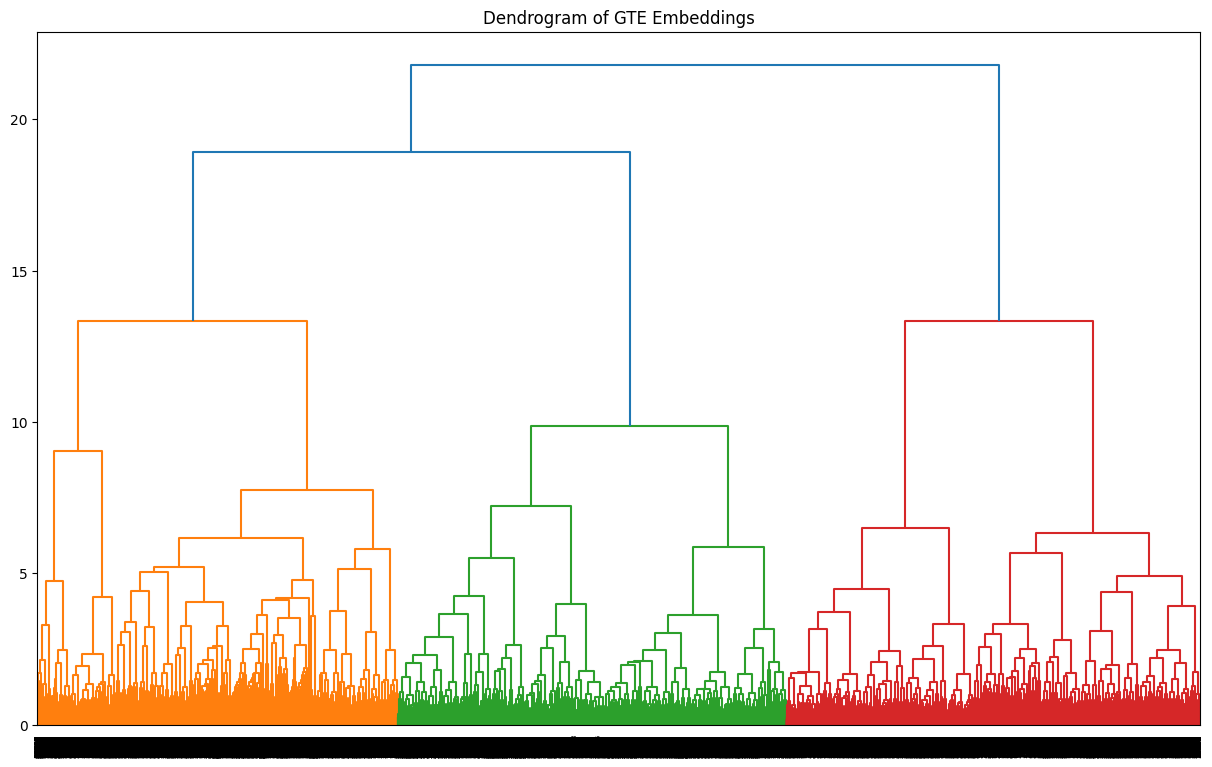

Dendrogram saved to /content/output_files/dendrogram.png


In [10]:
import os

link_model = linkage(list(df['vector']), 'ward') #ward 병합 기준으로

# Individual plot is no longer saved separately
plt.figure(figsize=(15,9))
dendrogram(link_model,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=False)
plt.title('Dendrogram of GTE Embeddings')

output_dir = '/content/output_files'
os.makedirs(output_dir, exist_ok=True)
dendrogram_filename = os.path.join(output_dir, 'dendrogram.png')
plt.savefig(dendrogram_filename)
plt.show()
print(f"Dendrogram saved to {dendrogram_filename}")
plt.close() # Close the plot to free memory

## UMAP

In [11]:
import umap
import matplotlib.pyplot as plt
import seaborn as sns

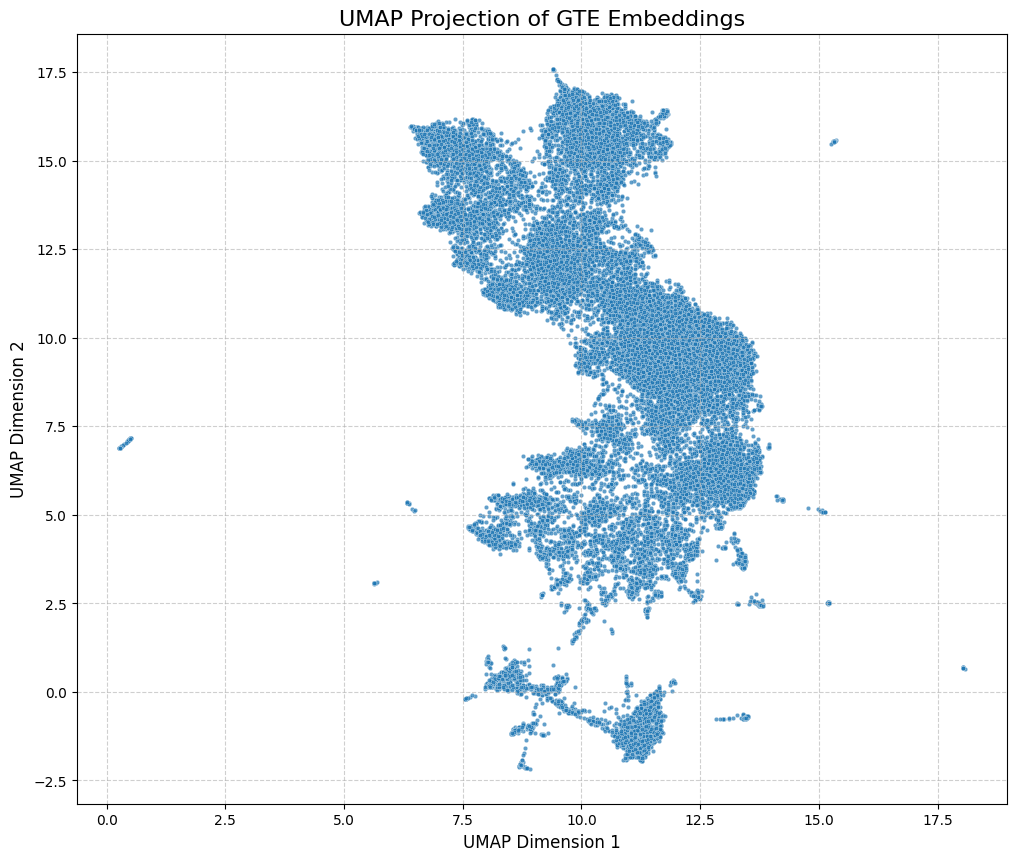

UMAP plot saved to /content/output_files/umap_projection.png


In [12]:
umap_reducer = umap.UMAP(n_components=2, random_state=42)

embedding = umap_reducer.fit_transform(list(df['vector']))

df['umap_x'] = embedding[:, 0]
df['umap_y'] = embedding[:, 1]

# Individual plot is no longer saved separately
plt.figure(figsize=(12, 10))
sns.scatterplot(
    x='umap_x',
    y='umap_y',
    data=df,
    s=10, # 점 크기
    alpha=0.7 # 투명도
)
plt.title('UMAP Projection of GTE Embeddings', fontsize=16)
plt.xlabel('UMAP Dimension 1', fontsize=12)
plt.ylabel('UMAP Dimension 2', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

output_dir = '/content/output_files'
os.makedirs(output_dir, exist_ok=True)
umap_filename = os.path.join(output_dir, 'umap_projection.png')
plt.savefig(umap_filename)
plt.show()
print(f"UMAP plot saved to {umap_filename}")
plt.close() # Close the plot to free memory

## PCA

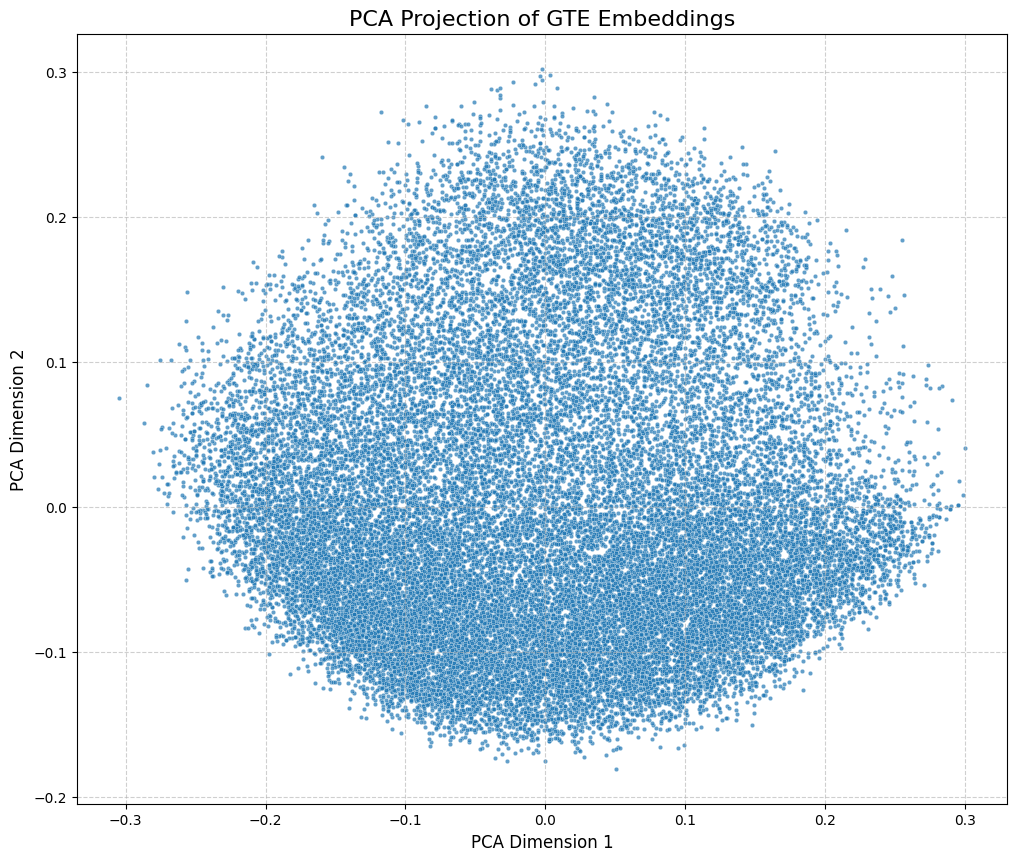

PCA plot saved to /content/output_files/pca_projection.png


In [13]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import os

# PCA 모델 설정
# n_components는 시각화를 위해 2로 설정합니다.
pca = PCA(n_components=2, random_state=42)

# Ko-SBERT 벡터에 PCA 적용
# result_df['vector']는 numpy array 형태로 변환되어야 합니다.
pca_embedding = pca.fit_transform(list(df['vector']))

# 차원 축소된 데이터를 DataFrame에 추가
df['pca_x'] = pca_embedding[:, 0]
df['pca_y'] = pca_embedding[:, 1]

# Individual plot is no longer saved separately
plt.figure(figsize=(12, 10))
sns.scatterplot(
    x='pca_x',
    y='pca_y',
    data=df,
    s=10, # 점 크기
    alpha=0.7 # 투명도
)
plt.title('PCA Projection of GTE Embeddings', fontsize=16)
plt.xlabel('PCA Dimension 1', fontsize=12)
plt.ylabel('PCA Dimension 2', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

output_dir = '/content/output_files'
os.makedirs(output_dir, exist_ok=True)
pca_filename = os.path.join(output_dir, 'pca_projection.png')
plt.savefig(pca_filename)
plt.show()
print(f"PCA plot saved to {pca_filename}")
plt.close() # Close the plot to free memory

## t-SNE

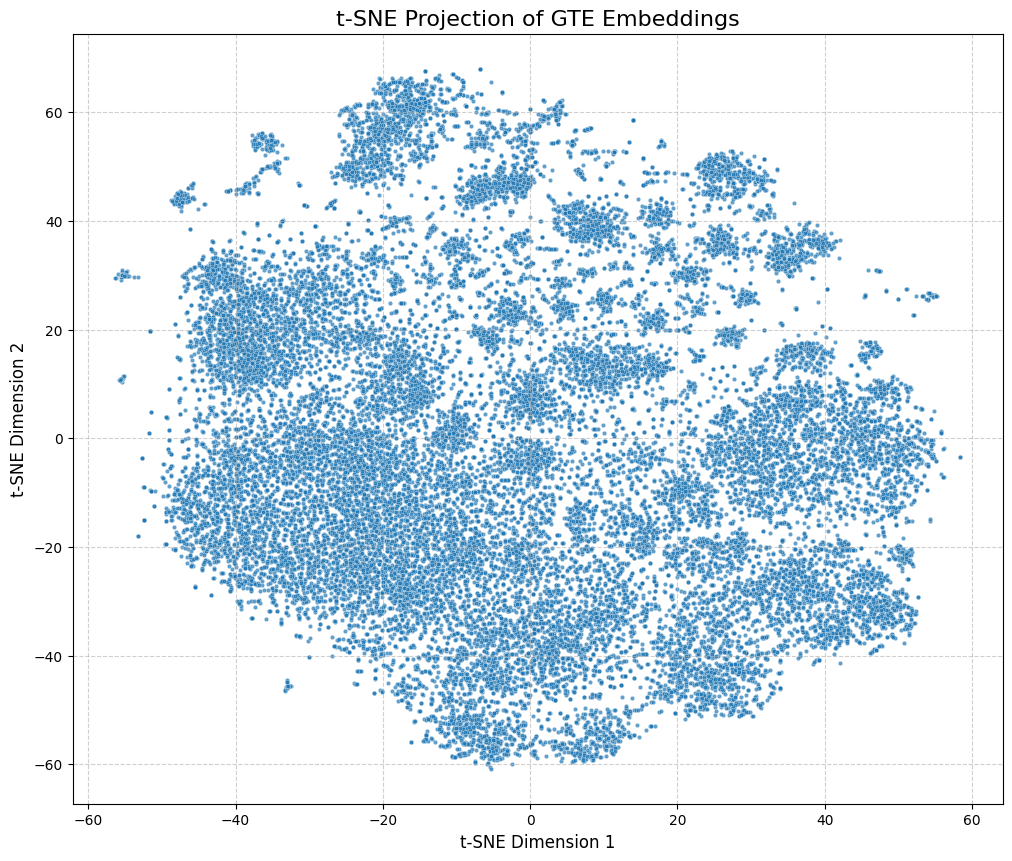

t-SNE plot saved to /content/output_files/tsne_projection.png


In [14]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # numpy import 추가
import os

# t-SNE 모델 설정
# n_components는 시각화를 위해 2로 설정합니다.
# perplexity, learning_rate, n_iter 등의 파라미터는 데이터에 따라 조정이 필요할 수 있습니다.
# random_state를 설정하여 결과의 재현성을 확보합니다.
tsne_model = TSNE(n_components=2, random_state=42, perplexity=30, learning_rate=200, n_iter=1000)

# Doc2Vec 벡터에 t-SNE 적용
# result_df['vector']는 numpy array 형태로 변환되어야 합니다.
# list(result_df['vector'])를 numpy 배열로 변환합니다.
tsne_embedding = tsne_model.fit_transform(np.array(list(df['vector'])))

# 차원 축소된 데이터를 DataFrame에 추가
df['tsne_x'] = tsne_embedding[:, 0]
df['tsne_y'] = tsne_embedding[:, 1]

# Individual plot is no longer saved separately
plt.figure(figsize=(12, 10))
sns.scatterplot(
    x='tsne_x',
    y='tsne_y',
    data=df,
    s=10, # 점 크기
    alpha=0.7 # 투명도
)
plt.title('t-SNE Projection of GTE Embeddings', fontsize=16)
plt.xlabel('t-SNE Dimension 1', fontsize=12)
plt.ylabel('t-SNE Dimension 2', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

output_dir = '/content/output_files'
os.makedirs(output_dir, exist_ok=True)
tsne_filename = os.path.join(output_dir, 'tsne_projection.png')
plt.savefig(tsne_filename)
plt.show()
print(f"t-SNE plot saved to {tsne_filename}")
plt.close() # Close the plot to free memory

## 파일 공유 드라이브에 저장

In [15]:
from googleapiclient.discovery import build
from googleapiclient.http import MediaFileUpload
import zipfile

os.makedirs(output_dir, exist_ok=True)

# 1. 데이터프레임 저장 (CSV)
df_filename = os.path.join(output_dir, 'processed_data.csv')
df.to_csv(df_filename, index=False)
print(f"DataFrame saved to {df_filename}")

# 2. 모든 결과 파일을 하나의 ZIP 파일로 압축
zip_filename = os.path.join(output_dir, 'GTE.zip')
with zipfile.ZipFile(zip_filename, 'w') as zf:
    if os.path.exists(df_filename):
        zf.write(df_filename, os.path.basename(df_filename))
    if os.path.exists(os.path.join(output_dir, 'dendrogram.png')):
        zf.write(os.path.join(output_dir, 'dendrogram.png'), os.path.basename(os.path.join(output_dir, 'dendrogram.png')))
    if os.path.exists(os.path.join(output_dir, 'umap_projection.png')):
        zf.write(os.path.join(output_dir, 'umap_projection.png'), os.path.basename(os.path.join(output_dir, 'umap_projection.png')))
    if os.path.exists(os.path.join(output_dir, 'pca_projection.png')):
        zf.write(os.path.join(output_dir, 'pca_projection.png'), os.path.basename(os.path.join(output_dir, 'pca_projection.png')))
    if os.path.exists(os.path.join(output_dir, 'tsne_projection.png')):
        zf.write(os.path.join(output_dir, 'tsne_projection.png'), os.path.basename(os.path.join(output_dir, 'tsne_projection.png')))
print(f"All results compressed into {zip_filename}")

# 3. Google Drive API를 사용하여 ZIP 파일 업로드
# Colab의 내장 인증 방식을 사용합니다.
drive_service = build('drive', 'v3')

if os.path.exists(zip_filename):
    file_metadata = {
        'name': os.path.basename(zip_filename),
        'parents': [drive_folder_id]
    }
    media = MediaFileUpload(zip_filename, resumable=True)
    uploaded_file = drive_service.files().create(
        body=file_metadata,
        media_body=media,
        fields='id'
    ).execute()
    print(f"Uploaded '{os.path.basename(zip_filename)}' to Google Drive folder ID: {drive_folder_id}. File ID: {uploaded_file.get('id')}")
else:
    print(f"Warning: ZIP file not found for upload - {zip_filename}")

print("All specified files have been processed and uploaded to Google Drive as a ZIP archive.")

DataFrame saved to /content/output_files/processed_data.csv


All results compressed into /content/output_files/GTE.zip
Uploaded 'GTE.zip' to Google Drive folder ID: 1teiRbwW4ciSrKLd4bvs7kc81Y5q3lkwV. File ID: 1jINTeOHowztUz289HDleeOgb3h3zCG3n
All specified files have been processed and uploaded to Google Drive as a ZIP archive.
